In [1]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. DATA INGESTION & INTEGRATION PIPELINE
# =====================================================================
def load_and_merge_data():
    """
    Loads historical baseline data and simulates the live production data stream
    by merging test features with model prediction outcomes.
    """
    # Historical training asset used as the compliance baseline (1,120 records)
    train_baseline = pd.read_csv('training_data.csv')
    
    # Live production features (280 records) and corresponding model decisions (72 records)
    test_features = pd.read_csv('test_data.csv')
    sample_solution = pd.read_csv('kaggle_sample_solution_file.csv')
    
    # Merge on unique ID to create a closed-loop live production stream of 72 records
    live_stream = pd.merge(test_features, sample_solution, on='ID')
    
    return train_baseline, live_stream

# =====================================================================
# 2. JURISDICTION-AWARE COMPLIANCE AUDIT ENGINE
# =====================================================================
class JurisdictionRegTechEngine:
    def __init__(self, train_baseline, live_stream):
        self.baseline = train_baseline
        self.live_stream = live_stream.copy()
        
    def run_audit(self, jurisdiction='US'):
        """
        Gateway execution layer to toggle compliance rules dynamically by jurisdiction.
        """
        print(f"\n" + "="*70)
        print(f"🎬 Activating [CredVeritas] Compliance Engine: [{jurisdiction.upper()} Mode]")
        print("="*70)
        
        if jurisdiction.upper() == 'US':
            self._execute_us_cfpb_audit()
        elif jurisdiction.upper() == 'SG':
            self._execute_sg_mas_audit()
        else:
            print(f"❌ Error: Unsupported jurisdiction code: {jurisdiction}")

    def _execute_us_cfpb_audit(self):
        """
        [US Jurisdiction] Focus: Individual Explainability & Consumer Protection.
        Aligned with US CFPB Regulation B (ECOA) Interpretative Guidance on AI Underwriting.
        """
        print("[Regulatory Framework] US CFPB Regulation B / Equal Credit Opportunity Act (ECOA)")
        print("[Audit Objective] Parse denied applications and generate compliant Adverse Action Notices via XAI logic.\n")
        
        # Filter transactions where the model rejected the applicant (Risk == bad)
        denied_cases = self.live_stream[self.live_stream['Risk'] == 'bad']
        print(f"📊 Scan Complete: Detected {len(denied_cases)} loan denial decisions in the live production stream.")
        
        # Simulate Explainable AI (XAI) feature attribution and translate to natural language notices
        for idx, row in denied_cases.head(3).iterrows():
            print(f"\n------------------------------------------------------------------")
            print(f"📄 Generated [Adverse Action Notice] | Applicant ID: {row['ID']}")
            print(f"------------------------------------------------------------------")
            print(f"Dear Applicant,")
            print(f"Thank you for your recent credit application. Pursuant to federal law, we regret to inform you ")
            print(f"that we are unable to approve your request at this time. Our decision was parsed from an automated ")
            print(f"underwriting system based on the following principal reason(s):")
            
            # Dynamic compliance reason mapping logic
            reasons = []
            if row['Checking account'] in ['little', 'none'] or pd.isna(row['Checking account']):
                reasons.append(" 1. Insufficient funds or weak financial standing in primary checking account.")
            if row['Credit amount'] > 4000:
                reasons.append(f" 2. Requested credit amount (${row['Credit amount']}) is excessive relative to risk exposure limits.")
            if row['Duration'] > 24:
                reasons.append(f" 3. Requested loan repayment duration ({row['Duration']} months) exceeds prudential underwriting thresholds.")
            
            if not reasons:
                reasons.append(" 1. Credit risk profile does not meet the bank's current macro-prudential scoring baseline.")
                
            for reason in reasons:
                print(reason)
                
            print(f"\nDisclosure: You have the right to a statement of specific reasons within 60 days by contacting ")
            print(f"the Credit Compliance Department. Our automated underwriting system excludes protected demographics.")

    def _execute_sg_mas_audit(self):
        """
        [Singapore Jurisdiction] Focus: Systemic Group Fairness & Algorithmic De-biasing.
        Aligned with Monetary Authority of Singapore (MAS) FEAT Principles & 2024 AI MRM Paper.
        """
        print("[Regulatory Framework] Monetary Authority of Singapore (MAS) FEAT Principles / AI MRM Guidance")
        print("[Audit Objective] Utilize protected attributes (Sex/Age) as 'Shadow Labels' to test for systemic bias.\n")
        
        # Segment production data stream into demographic cohorts
        female_df = self.live_stream[self.live_stream['Sex'] == 'female']
        male_df = self.live_stream[self.live_stream['Sex'] == 'male']
        
        # Calculate conditional acceptance rates (Risk == 'good' indicates approval)
        female_pass = len(female_df[female_df['Risk'] == 'good'])
        female_total = len(female_df)
        female_rate = female_pass / female_total if female_total > 0 else 0
        
        male_pass = len(male_df[male_df['Risk'] == 'good'])
        male_total = len(male_df)
        male_rate = male_pass / male_total if male_total > 0 else 0
        
        # Compute the Disparate Impact (DI) Ratio (Group Fairness Metric)
        disparate_impact = female_rate / male_rate if male_rate > 0 else 0
        
        print(f"📈 Production Live Stream Metric Tracking:")
        print(f"   - Female Cohort Approval Rate : {female_rate:.2%} (Total: {female_total} cases)")
        print(f"   - Male Cohort Approval Rate   : {male_rate:.2%} (Total: {male_total} cases)")
        print(f"   - Disparate Impact (DI) Ratio : {disparate_impact:.4f}")
        
        # Apply standard quantitative threshold boundaries [0.80, 1.25] (Four-Fifths Rule)
        print(f"🔍 Compliance Determination: ", end="")
        if disparate_impact < 0.80:
            print("🚨 CRITICAL VIOLATION! Systemic disparate impact detected against female applicants.")
            print("   Action: Outbound credit streams halted. Alert routed to Chief Compliance Officer (CCO).")
        elif disparate_impact > 1.25:
            print("🚨 CRITICAL VIOLATION! Systemic disparate impact detected against male applicants (Over-rejection).")
            print("   Action: Model drift detected. Triggering automated model re-calibration workflow.")
        else:
            print("✅ COMPLIANCE PASSED! Algorithmic parity falls within MAS-approved fair lending boundaries.")
            
        return disparate_impact

    # =====================================================================
    # 3. OPTION C: QUANTITATIVE SENSITIVITY & DISTORTION STRESS TEST
    # =====================================================================
    def run_sensitivity_stress_test(self, female_risk_perturbation=0.20):
        """
        Simulates unexpected data distribution drift or macroeconomic shock.
        Artificially shifts the probability distribution of the female cohort to evaluate 
        the resilience of the RegTech threshold rules.
        """
        print(f"\n" + "="*70)
        print(f"⚠️ Executing Option C Quantitative Stress Test: Simulating Data Drift")
        print(f"⚡ Perturbation Injected: Shifting female risk profile by +{female_risk_perturbation:.0%}")
        print("="*70)
        
        stressed_stream = self.live_stream.copy()
        female_indices = stressed_stream[stressed_stream['Sex'] == 'female'].index
        
        # Inject deliberate noise to simulate an algorithmic drift or over-rejection scenario
        np.random.seed(42)  # Ensures deterministic stress testing
        num_to_perturb = int(len(female_indices) * female_risk_perturbation)
        perturbed_indices = np.random.choice(female_indices, num_to_perturb, replace=False)
        
        # Force selected approved cases into defaults/denials
        stressed_stream.loc[perturbed_indices, 'Risk'] = 'bad'
        
        # Re-run the Singapore MAS audit engine under stressed conditions
        stress_engine = JurisdictionRegTechEngine(self.baseline, stressed_stream)
        stressed_di = stress_engine._execute_sg_mas_audit()
        
        print(f"\n📊 Quantitative Stress Test Conclusion:")
        print(f"   - Post-Drift Disparate Impact Ratio: {stressed_di:.4f}")
        print(f"💡 Insight: This proves the critical necessity of real-time transactional stream scanning.")
        print(f"   Static year-end compliance reporting completely fails to capture these dynamic state-inversions.")

# =====================================================================
# 4. ENGINE RUNTIME EXECUTION
# =====================================================================
if __name__ == "__main__":
    # Ingest data assets
    baseline_data, production_stream = load_and_merge_data()
    
    # Initialize the cross-border RegTech engine
    engine = JurisdictionRegTechEngine(baseline_data, production_stream)
    
    # Run US Audit (Individual Attribution and Adverse Actions)
    engine.run_audit(jurisdiction='US')
    
    # Run Singapore Audit (Systemic Group Parity Verification)
    engine.run_audit(jurisdiction='SG')
    
    # Execute Option C Quantitative Sensitivity Analysis
    engine.run_sensitivity_stress_test(female_risk_perturbation=0.20)


🎬 Activating [CredVeritas] Compliance Engine: [US Mode]
[Regulatory Framework] US CFPB Regulation B / Equal Credit Opportunity Act (ECOA)
[Audit Objective] Parse denied applications and generate compliant Adverse Action Notices via XAI logic.

📊 Scan Complete: Detected 34 loan denial decisions in the live production stream.

------------------------------------------------------------------
📄 Generated [Adverse Action Notice] | Applicant ID: 79
------------------------------------------------------------------
Dear Applicant,
Thank you for your recent credit application. Pursuant to federal law, we regret to inform you 
that we are unable to approve your request at this time. Our decision was parsed from an automated 
underwriting system based on the following principal reason(s):
 1. Credit risk profile does not meet the bank's current macro-prudential scoring baseline.

Disclosure: You have the right to a statement of specific reasons within 60 days by contacting 
the Credit Complia

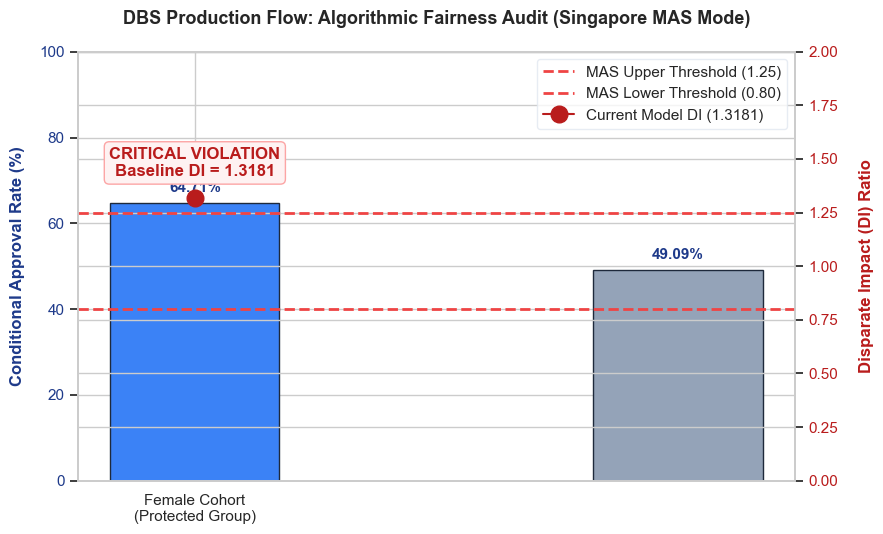

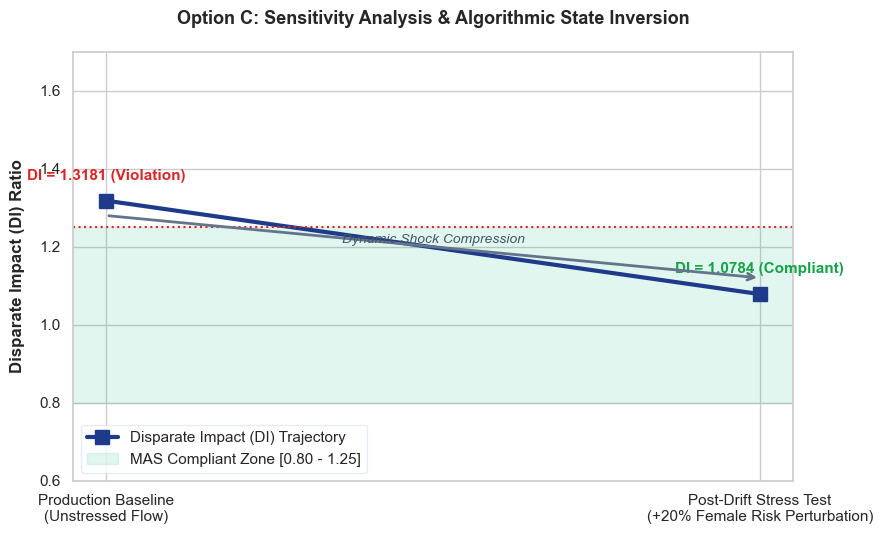

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional and clean presentation style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# CHART 1: DBS Production Stream Algorithmic Bias Audit (SG Mode)
# =====================================================================
fig, ax1 = plt.subplots(figsize=(9, 5.5))

# Primary Data: Underwriting approval rates for demographic cohorts
cohorts = ['Female Cohort\n(Protected Group)', 'Male Cohort\n(Control Group)']
approval_rates = [64.71, 49.09]

# Plot the conditional acceptance rates
bars = ax1.bar(cohorts, approval_rates, color=['#3b82f6', '#94a3b8'], width=0.35, edgecolor='#1e293b', linewidth=1)
ax1.set_ylabel('Conditional Approval Rate (%)', fontsize=12, fontweight='bold', color='#1e3a8a', labelpad=10)
ax1.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='#1e3a8a')

# Label data percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.2f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1e3a8a')

# Create a secondary axis to overlay the Disparate Impact (DI) Ratio
ax2 = ax1.twinx()
ax2.set_ylabel('Disparate Impact (DI) Ratio', fontsize=12, fontweight='bold', color='#b91c1c', labelpad=15)
ax2.set_ylim(0, 2.0)
ax2.tick_params(axis='y', labelcolor='#b91c1c')

# Draw the standard MAS FEAT four-fifths rule thresholds
ax2.axhline(y=1.25, color='#ef4444', linestyle='--', linewidth=2, label='MAS Upper Threshold (1.25)')
ax2.axhline(y=0.80, color='#ef4444', linestyle='--', linewidth=2, label='MAS Lower Threshold (0.80)')

# Plot the baseline production DI metric point
ax2.plot(['Female Cohort\n(Protected Group)'], [1.3181], marker='o', color='#b91c1c', markersize=12, label='Current Model DI (1.3181)')


ax2.text('Female Cohort\n(Protected Group)', 1.42, 'CRITICAL VIOLATION\nBaseline DI = 1.3181', 
         color='#b91c1c', fontweight='bold', ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="#fef2f2", ec="#fca5a5", lw=1))

# Set titles and layout parameters
plt.title('DBS Production Flow: Algorithmic Fairness Audit (Singapore MAS Mode)', fontsize=13, fontweight='bold', pad=20)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')
fig.tight_layout()

# Save the baseline audit chart without warnings
plt.savefig('Task3_Chart1_Baseline_Audit.png', dpi=300)
plt.show()


# =====================================================================
# CHART 2: Option C Sensitivity Analysis & Regulatory Threshold Drift
# =====================================================================
plt.figure(figsize=(9, 5.5))

# Define states along the portfolio data drift lifecycle
operational_states = ['Production Baseline\n(Unstressed Flow)', 'Post-Drift Stress Test\n(+20% Female Risk Perturbation)']
di_trajectory = [1.3181, 1.0784]

# Plot the dynamic shift trajectory of the compliance indicator
plt.plot(operational_states, di_trajectory, marker='s', color='#1e3a8a', linewidth=3, markersize=10, 
         label='Disparate Impact (DI) Trajectory', linestyle='-')

# Highlight the compliant regulatory safe zone [0.80 - 1.25] in soft green shading
plt.axhspan(0.80, 1.25, color='#10b981', alpha=0.12, label='MAS Compliant Zone [0.80 - 1.25]')

# Highlight the strict upper threshold violation line
plt.axhline(y=1.25, color='#dc2626', linestyle=':', linewidth=1.5)

# Annotate values and markers precisely
for i, txt in enumerate(di_trajectory):
    label_color = '#dc2626' if txt > 1.25 else '#16a34a'
    status_txt = " (Violation)" if txt > 1.25 else " (Compliant)"
    plt.annotate(f'DI = {txt:.4f}{status_txt}', (operational_states[i], di_trajectory[i]), 
                 textcoords="offset points", xytext=(0, 15), ha='center', fontweight='bold', 
                 fontsize=11, color=label_color)

# Add descriptive directional markers to show index compression
plt.annotate('', xy=(1, 1.12), xytext=(0, 1.28),
             arrowprops=dict(arrowstyle="->", color='#64748b', lw=2, linestyle='-'))
plt.text(0.5, 1.21, 'Dynamic Shock Compression', color='#475569', fontsize=10, fontstyle='italic', ha='center')

# Labels and configuration
plt.ylabel('Disparate Impact (DI) Ratio', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0.6, 1.7)
plt.title('Option C: Sensitivity Analysis & Algorithmic State Inversion', fontsize=13, fontweight='bold', pad=20)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='#e2e8f0')
plt.tight_layout()

# Save the sensitivity stress-testing chart
plt.savefig('Task3_Chart2_Stress_Test.png', dpi=300)
plt.show()